# 時間序列(Time Series)預測 

## 載入相關套件 

In [1]:
import math
from typing import List, Tuple, cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from torch import nn, optim
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler

## 判斷GPU是否存在

In [2]:
device = "cuda" if torch.cuda.is_available() else "mps" if torch.mps.is_available() else "cpu"
device

'mps'

## 載入資料

In [3]:
df = pd.read_csv('nlp_data/airline-passengers.csv')
df.head()

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df.tail()

,Month,Passengers
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390
143,1960-12,432


(array([-20.,   0.,  20.,  40.,  60.,  80., 100., 120., 140., 160.]),
 [Text(-20.0, 0, '1959-05'),
  Text(0.0, 0, '1949-01'),
  Text(20.0, 0, '1950-09'),
  Text(40.0, 0, '1952-05'),
  Text(60.0, 0, '1954-01'),
  Text(80.0, 0, '1955-09'),
  Text(100.0, 0, '1957-05'),
  Text(120.0, 0, '1959-01'),
  Text(140.0, 0, '1960-09'),
  Text(160.0, 0, '')])

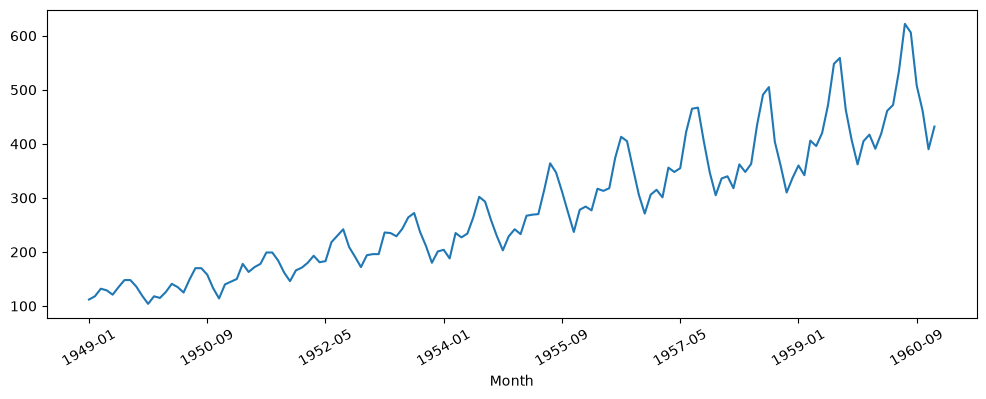

In [5]:
# 繪圖
df2 = df.set_index('Month')
df2.plot(legend=False, figsize=(12, 4))
plt.xticks(rotation=30)

In [6]:
len(df2)

144

In [7]:
look_back = 1  # 以前N期資料為 X，當期資料為 Y


# 函數：以前N期資料為 X，當前期資料為 Y
def create_dataset(data: np.ndarray, look_back: int) -> Tuple[torch.Tensor, torch.Tensor]:
    x: List[np.ndarray] = []
    y: List[np.ndarray] = []
    for i in range(len(data) - look_back - 1):
        _x = data[i : (i + look_back)]
        _y = data[i + look_back]
        x.append(_x)
        y.append(_y)

    return torch.Tensor(np.array(x)).to(device), torch.Tensor(np.array(y)).to(device)


dataset = df2[['Passengers']].values.astype('float32')

# X 常態化
scaler = MinMaxScaler()
dataset = scaler.fit_transform(dataset)

# 資料分割
train_size = int(len(dataset) * 0.67)
test_size = len(dataset) - train_size
train_data, test_data = dataset[0:train_size, :], dataset[train_size : len(dataset), :]

trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)
dataset.shape, trainY.shape

((144, 1), torch.Size([94, 1]))

In [8]:
dataset[-1]

array([0.6332046], dtype=float32)

In [9]:
trainX.shape, trainY.shape, testX.shape, testY.shape

(torch.Size([94, 1, 1]),
 torch.Size([94, 1]),
 torch.Size([46, 1, 1]),
 torch.Size([46, 1]))

In [10]:
torch.cat((trainX.reshape(trainX.shape[0], trainX.shape[1]), trainY), dim=1)

tensor([[0.0154, 0.0270],
        [0.0270, 0.0541],
        [0.0541, 0.0483],
        [0.0483, 0.0328],
        [0.0328, 0.0598],
        [0.0598, 0.0849],
        [0.0849, 0.0849],
        [0.0849, 0.0618],
        [0.0618, 0.0290],
        [0.0290, 0.0000],
        [0.0000, 0.0270],
        [0.0270, 0.0212],
        [0.0212, 0.0425],
        [0.0425, 0.0714],
        [0.0714, 0.0598],
        [0.0598, 0.0405],
        [0.0405, 0.0869],
        [0.0869, 0.1274],
        [0.1274, 0.1274],
        [0.1274, 0.1042],
        [0.1042, 0.0560],
        [0.0560, 0.0193],
        [0.0193, 0.0695],
        [0.0695, 0.0792],
        [0.0792, 0.0888],
        [0.0888, 0.1429],
        [0.1429, 0.1139],
        [0.1139, 0.1313],
        [0.1313, 0.1429],
        [0.1429, 0.1834],
        [0.1834, 0.1834],
        [0.1834, 0.1544],
        [0.1544, 0.1120],
        [0.1120, 0.0811],
        [0.0811, 0.1197],
        [0.1197, 0.1293],
        [0.1293, 0.1467],
        [0.1467, 0.1718],
        [0.1

## 建立模型

In [11]:
class TimeSeriesModel(nn.Module):
    def __init__(self, hidden_size: int = 4, num_layers: int = 1):
        super().__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.rnn = nn.GRU(1, hidden_size, num_layers=num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, 1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.5
        self.fc.weight.data.uniform_(-initrange, initrange)
        self.fc.bias.data.zero_()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # print(x.shape)
        # rnn_out, h_out = self.rnn(x)
        h_0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size, device=x.device)
        out, h_out = self.rnn(x, h_0)
        # print(h_out.shape)

        # 取最後一層的 h，並轉成二維
        h_out = cast(torch.Tensor, h_out)[-1].view(-1, self.hidden_size)
        return self.fc(h_out)


model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)

## 模型訓練

In [12]:
num_epochs = 2000
learning_rate = 0.01


def train(trainX: torch.Tensor, trainY: torch.Tensor):
    criterion = nn.MSELoss()  # MSE
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    for epoch in range(num_epochs):
        optimizer.zero_grad()
        outputs: torch.Tensor = model(trainX)
        if epoch <= 0:
            print(outputs.shape)
        loss: torch.Tensor = criterion(outputs, trainY)
        loss.backward()
        optimizer.step()
        if epoch % 100 == 0:
            print(f"Epoch: {epoch}, loss: {loss.item():.5f}")


train(trainX, trainY)

torch.Size([94, 1])
Epoch: 0, loss: 0.04174
Epoch: 100, loss: 0.00203
Epoch: 200, loss: 0.00194
Epoch: 300, loss: 0.00192
Epoch: 400, loss: 0.00191
Epoch: 500, loss: 0.00190
Epoch: 600, loss: 0.00190
Epoch: 700, loss: 0.00190
Epoch: 800, loss: 0.00190
Epoch: 900, loss: 0.00190
Epoch: 1000, loss: 0.00190
Epoch: 1100, loss: 0.00190
Epoch: 1200, loss: 0.00190
Epoch: 1300, loss: 0.00190
Epoch: 1400, loss: 0.00190
Epoch: 1500, loss: 0.00190
Epoch: 1600, loss: 0.00190
Epoch: 1700, loss: 0.00190
Epoch: 1800, loss: 0.00190
Epoch: 1900, loss: 0.00190


## 模型評估

In [13]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()
trainPredict.shape

(94, 1)

In [14]:
trainY.shape, trainPredict.shape

(torch.Size([94, 1]), (94, 1))

In [15]:
# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(94, 1) (94, 1)
Train RMSE: 22.57
Test RMSE:  54.07


## 繪製實際資料和預測資料的圖表

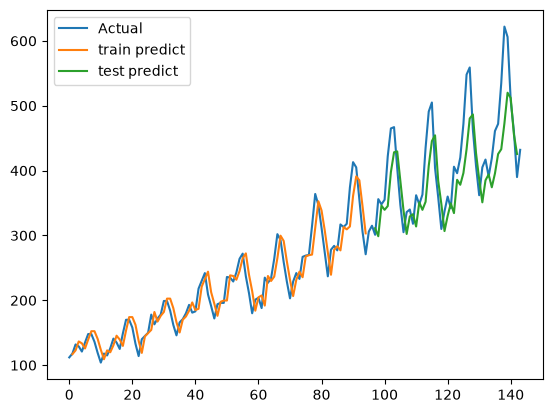

In [16]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : len(trainPredict) + look_back, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## 改變Loopback=3：X由前1期改為前3期 

In [17]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=1).to(device)
train(trainX, trainY)

torch.Size([92, 1])
Epoch: 0, loss: 0.05118
Epoch: 100, loss: 0.00248
Epoch: 200, loss: 0.00197
Epoch: 300, loss: 0.00177
Epoch: 400, loss: 0.00169
Epoch: 500, loss: 0.00165
Epoch: 600, loss: 0.00163
Epoch: 700, loss: 0.00160
Epoch: 800, loss: 0.00158
Epoch: 900, loss: 0.00156
Epoch: 1000, loss: 0.00154
Epoch: 1100, loss: 0.00152
Epoch: 1200, loss: 0.00151
Epoch: 1300, loss: 0.00150
Epoch: 1400, loss: 0.00149
Epoch: 1500, loss: 0.00148
Epoch: 1600, loss: 0.00146
Epoch: 1700, loss: 0.00142
Epoch: 1800, loss: 0.00140
Epoch: 1900, loss: 0.00138


In [18]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(92, 1) (92, 1)
Train RMSE: 19.04
Test RMSE:  91.46


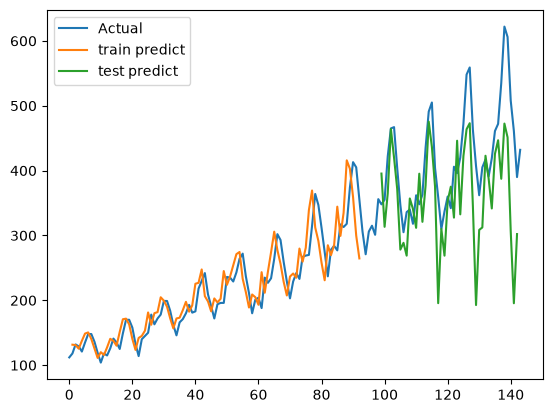

In [19]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()

## Stacked GRU

In [20]:
# 以前期資料為 X，當前期資料為 Y
look_back = 3
trainX, trainY = create_dataset(train_data, look_back)
testX, testY = create_dataset(test_data, look_back)

model = TimeSeriesModel(hidden_size=4, num_layers=3).to(device)
train(trainX, trainY)

torch.Size([92, 1])
Epoch: 0, loss: 0.02453
Epoch: 100, loss: 0.00345
Epoch: 200, loss: 0.00159
Epoch: 300, loss: 0.00149
Epoch: 400, loss: 0.00147
Epoch: 500, loss: 0.00145
Epoch: 600, loss: 0.00138
Epoch: 700, loss: 0.00134
Epoch: 800, loss: 0.00128
Epoch: 900, loss: 0.00120
Epoch: 1000, loss: 0.00109
Epoch: 1100, loss: 0.00099
Epoch: 1200, loss: 0.00090
Epoch: 1300, loss: 0.00081
Epoch: 1400, loss: 0.00075
Epoch: 1500, loss: 0.00086
Epoch: 1600, loss: 0.00069
Epoch: 1700, loss: 0.00069
Epoch: 1800, loss: 0.00065
Epoch: 1900, loss: 0.00071


In [21]:
model.eval()
trainPredict = cast(torch.Tensor, model(trainX)).detach().cpu().numpy()
testPredict = cast(torch.Tensor, model(testX)).detach().cpu().numpy()

# 還原常態化的訓練及測試資料
trainPredict = scaler.inverse_transform(trainPredict)
trainY_actual = scaler.inverse_transform(trainY.detach().cpu().numpy().reshape(-1, 1))
testPredict = scaler.inverse_transform(testPredict)
testY_actual = scaler.inverse_transform(testY.detach().cpu().numpy().reshape(-1, 1))
print(trainY_actual.shape, trainPredict.shape)

# 計算 RMSE
trainScore = math.sqrt(mean_squared_error(trainY_actual, trainPredict.reshape(-1)))
print(f'Train RMSE: {trainScore:.2f}')
testScore = math.sqrt(mean_squared_error(testY_actual, testPredict.reshape(-1)))
print(f'Test RMSE:  {testScore:.2f}')

(92, 1) (92, 1)
Train RMSE: 12.92
Test RMSE:  96.63


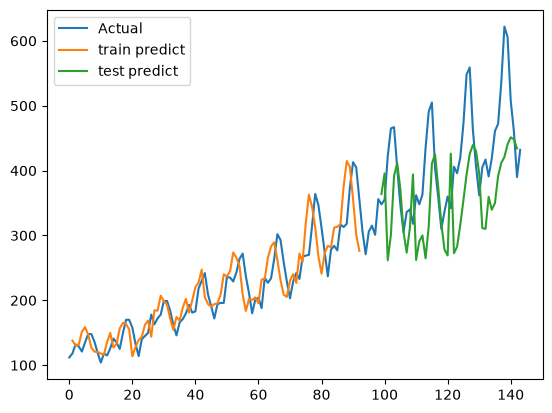

In [22]:
# 訓練資料的 X/Y
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[1 : trainPredict.shape[0] + 1 :, :] = trainPredict

# 測試資料 X/Y
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[-testPredict.shape[0] - 1 : -1, :] = testPredict

# 繪圖
plt.plot(scaler.inverse_transform(dataset), label='Actual')
plt.plot(trainPredictPlot, label='train predict')
plt.plot(testPredictPlot, label='test predict')
plt.legend()
plt.show()